In [3]:
# --------------------──────────────────────────────────────────
# ## Etapa 2 — Triagem por tecnologia habilitadora
#
# A base inicial retornou 72 artigos Open Access sobre qualidade
# na Indústria 4.0. Esta etapa aplica um filtro por tecnologia
# específica (IoT, ML, Computer Vision, Digital Twin, Sensores)
# nos campos Título e Resumo, isolando os estudos com aplicação
# técnica direta — a "Amostra Ouro" do e-book.
# ─-────────────────────────────────────────────────────────────

import pandas as pd
import re

# Carregamento
df = pd.read_excel('/content/e-book_acesso-aberto_72docs.xls')

print(f"Base inicial: {len(df)} artigos")
print(f"Colunas disponíveis: {df.columns.tolist()}")

Base inicial: 72 artigos
Colunas disponíveis: ['Publication Type', 'Authors', 'Book Authors', 'Book Editors', 'Book Group Authors', 'Author Full Names', 'Book Author Full Names', 'Group Authors', 'Article Title', 'Source Title', 'Book Series Title', 'Book Series Subtitle', 'Language', 'Document Type', 'Conference Title', 'Conference Date', 'Conference Location', 'Conference Sponsor', 'Conference Host', 'Author Keywords', 'Keywords Plus', 'Abstract', 'Addresses', 'Affiliations', 'Reprint Addresses', 'Email Addresses', 'Researcher Ids', 'ORCIDs', 'Funding Orgs', 'Funding Name Preferred', 'Funding Text', 'Cited References', 'Cited Reference Count', 'Times Cited, WoS Core', 'Times Cited, All Databases', '180 Day Usage Count', 'Since 2013 Usage Count', 'Publisher', 'Publisher City', 'Publisher Address', 'ISSN', 'eISSN', 'ISBN', 'Journal Abbreviation', 'Journal ISO Abbreviation', 'Publication Date', 'Publication Year', 'Volume', 'Issue', 'Part Number', 'Supplement', 'Special Issue', 'Meeting

Source Title
APPLIED SCIENCES-BASEL                                       5
SUSTAINABILITY                                               5
IEEE ACCESS                                                  5
PROCESSES                                                    3
MACHINES                                                     3
JOURNAL OF INTELLIGENT MANUFACTURING                         3
ROBOTICS AND COMPUTER-INTEGRATED MANUFACTURING               2
INTERNATIONAL JOURNAL OF QUALITY & RELIABILITY MANAGEMENT    2
MATHEMATICAL PROBLEMS IN ENGINEERING                         2
ADVANCES IN PRODUCTION ENGINEERING & MANAGEMENT              2
Name: count, dtype: int64


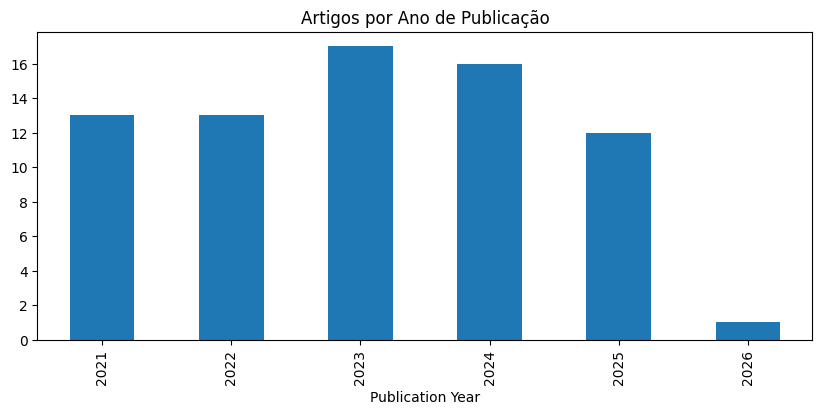

In [4]:
# -------------------──────────────────────────────────────────
# ### Exploração rápida antes da triagem
# ─────────────────────────────────────────────────────────────

# Distribuição por ano
df['Publication Year'].value_counts().sort_index().plot(
    kind='bar', title='Artigos por Ano de Publicação', figsize=(10,4)
)

# Top periódicos
print(df['Source Title'].value_counts().head(10))

In [5]:
# -------------------──────────────────────────────────────────
# ### Critério de triagem
# Tecnologias habilitadoras selecionadas com base na revisão
# de literatura sobre Qualidade 4.0: Machine Vision, IoT,
# Digital Twin, Machine Learning, AI e Sensores.
# ─────────────────────────────────────────────────────────────

regex_tecnologia = r'\b(machine vision|computer vision|digital twin\w*|iot|internet of things|machine learning|artificial intelligence|ai|sensor\w*)\b'

col_titulo = 'Article Title'
col_resumo = 'Abstract'

df[col_titulo] = df[col_titulo].fillna('')
df[col_resumo] = df[col_resumo].fillna('')

mascara = (
    df[col_titulo].str.contains(regex_tecnologia, flags=re.IGNORECASE, regex=True) |
    df[col_resumo].str.contains(regex_tecnologia, flags=re.IGNORECASE, regex=True)
)

df_final = df[mascara].copy()

print(f"Antes: {len(df)} artigos")
print(f"Depois: {len(df_final)} artigos ({len(df_final)/len(df)*100:.1f}% retidos)")

# Mostra os primeiros resultados no notebook
df_final[[col_titulo, 'Publication Year', 'Source Title']].head(10)

Antes: 72 artigos
Depois: 37 artigos (51.4% retidos)


/tmp/ipykernel_42379/2179968898.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[col_titulo].str.contains(regex_tecnologia, flags=re.IGNORECASE, regex=True) |
/tmp/ipykernel_42379/2179968898.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[col_resumo].str.contains(regex_tecnologia, flags=re.IGNORECASE, regex=True)


,Article Title,Publication Year,Source Title
1,Bridging the gap between Industry 4.0 and manu...,2025,JOURNAL OF INDUSTRIAL INFORMATION INTEGRATION
7,A Sustainable Productive Method for Enhancing ...,2022,SUSTAINABILITY
9,Digital twins-based remote semi-physical commi...,2021,JOURNAL OF CLEANER PRODUCTION
10,A Digital Twin-Assisted Collaborative Capabili...,2023,IEEE ACCESS
18,Hyperconnectivity Proposal for Smart Manufactu...,2023,IEEE ACCESS
19,Designing and developing smart production plan...,2022,JOURNAL OF INTELLIGENT MANUFACTURING
20,Towards Customer Outcome Management in Smart M...,2023,MACHINES
21,An implementation model for digitisation of vi...,2023,INTERNATIONAL JOURNAL OF LEAN SIX SIGMA
22,A Data Quality Pipeline for Industrial Environ...,2025,COMPUTERS
27,Towards scalable and reusable predictive model...,2022,JOURNAL OF INTELLIGENT MANUFACTURING


<Axes: title={'center': 'Frequência de tecnologias na amostra final'}>

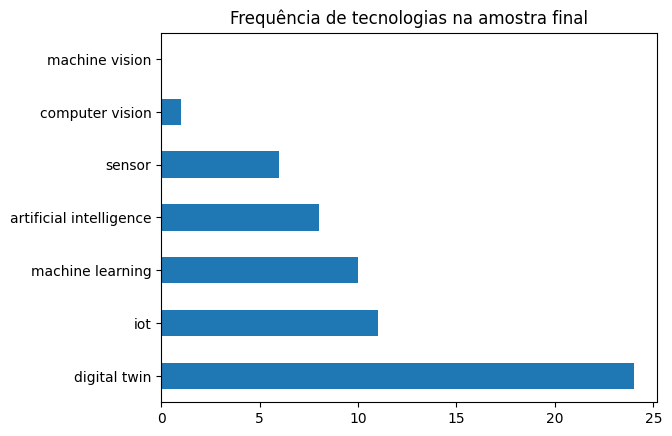

In [7]:
# Quais tecnologias apareceram — frequência de cada termo
termos = ['machine vision', 'computer vision', 'digital twin',
          'iot', 'machine learning', 'artificial intelligence', 'sensor']

frequencias = {
    termo: df_final[col_titulo].str.contains(termo, case=False).sum() +
           df_final[col_resumo].str.contains(termo, case=False).sum()
    for termo in termos
}

pd.Series(frequencias).sort_values(ascending=False).plot(
    kind='barh', title='Frequência de tecnologias na amostra final'
)

In [17]:
for termo in termos:
    df_final[f'tag_{termo.replace(" ", "_")}'] = (
        df_final[col_titulo].str.contains(termo, case=False) |
        df_final[col_resumo].str.contains(termo, case=False)
    ).astype(int)



<Figure size 1200x700 with 0 Axes>

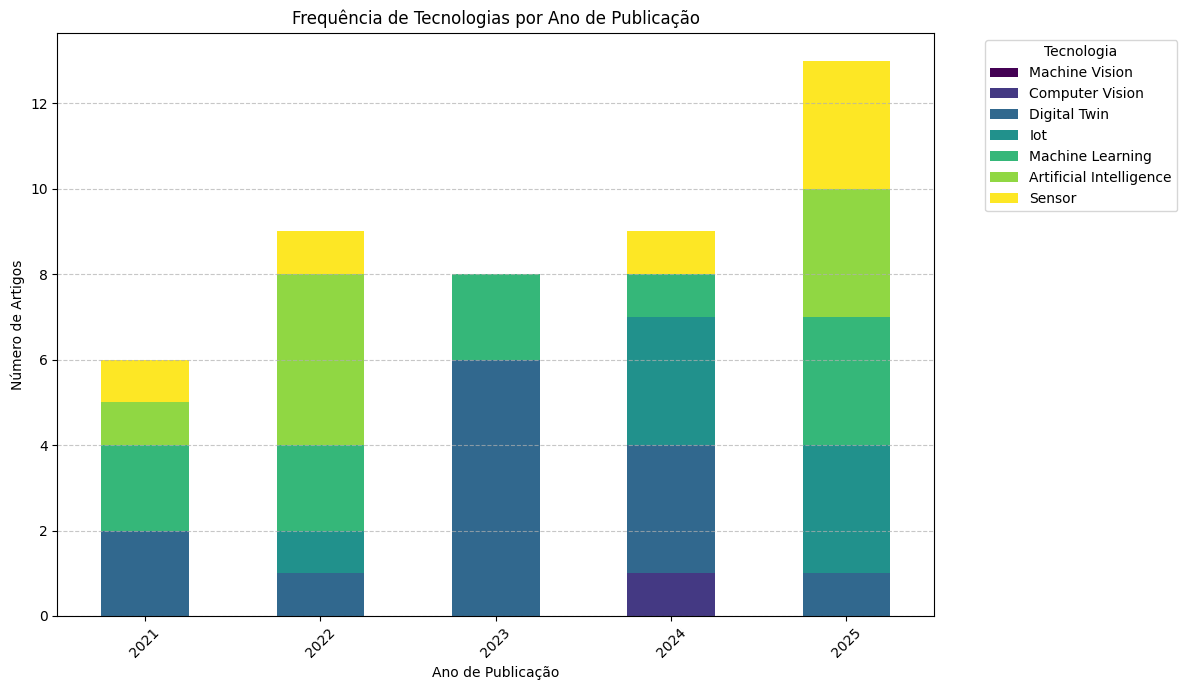

In [13]:
import matplotlib.pyplot as plt

# Create a list of tag columns
tag_columns = [f'tag_{termo.replace(" ", "_")}' for termo in termos]

# Group by 'Publication Year' and sum the tag columns
yearly_technology_counts = df_final.groupby('Publication Year')[tag_columns].sum()

# Rename columns for better readability in the plot
year_tech_counts_renamed = yearly_technology_counts.rename(columns=lambda x: x.replace('tag_', '').replace('_', ' ').title())

# Plotting the stacked bar chart
plt.figure(figsize=(12, 7))
year_tech_counts_renamed.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='viridis'
)

plt.title('Frequência de Tecnologias por Ano de Publicação')
plt.xlabel('Ano de Publicação')
plt.ylabel('Número de Artigos')
plt.xticks(rotation=45)
plt.legend(title='Tecnologia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Define the path to save the Excel file in Google Drive
output_path = '/content/drive/MyDrive/df_final_tecnologias.xlsx'

# Export df_final to an Excel file
df_final.to_excel(output_path, index=False)

print(f"DataFrame 'df_final' exportado com sucesso para: {output_path}")

DataFrame 'df_final' exportado com sucesso para: /content/drive/MyDrive/df_final_tecnologias.xlsx
